<a href="https://colab.research.google.com/github/michamettler/zhaw-xai/blob/main/03_Counterf_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## XAI Lab: Influence Functions and Counterfactuals

In [3]:
pip install dice-ml "pandas<3"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 47.9 MB/s eta 0:00:00


In [4]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
import torchvision.models as models
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import NearestNeighbors

import dice_ml

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

Complete the coding exercises below.

#### Influence Functions:
- **Task (0.5 points):** Fine-tune the given model on the image dataset.
- **Task (1 point):** Using the helper functions, compute influence scores for a subset of training examples for a selected test image.
- **Task (1 point):** Plot the most influential training images for the chosen test image.

#### Counterfactuals (using DiCE library):
- **Task (0.5 points):** Train a logistic regression on the tabular dataset given.
- **Task (1.5 points):** Select a negatively predicted test instance and use DiCE to generate baseline counterfactual examples. Show the feature values of the original and the counterfactual.
- **Task (1.5 points):** Use DiCE's `features_to_vary` to add feasibility constraints to prevent changes to the subset of features that cannot be modified (analyse the features to determine that subset) and compare results.
- **Task (1.5 points):** Add the causal constraints given and generate counterfactuals again. Compare results.
- **Task (1.5 points):** Use DiCE's `kdtree` method to construct on-manifold counterfactuals. Compare all results.
- **Task (1 point):** Create a dot plot showing which numerical and categorical features changed for a selected test instance across the base, feasible, causal and manifold counterfactuals.

### Coding Tasks

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

transform = T.Compose([
    T.Resize(224),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

class_names = train_dataset.classes

100%|██████████| 170M/170M [00:03<00:00, 48.6MB/s]


**Task (0.5 points):** Fine-tune the given model on the image dataset.

In [6]:
model = models.resnet18(pretrained=True)
model.fc = torch.nn.Linear(model.fc.in_features, 10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 74.8MB/s]


In [7]:
## Your solution here here ..

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

model.train()
for epoch in range(1):
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.squeeze().long().to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [9]:
def get_grad_vector(model, x, y):
    model.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, y)
    grads = torch.autograd.grad(loss, model.parameters())
    grad_vector = torch.cat([g.contiguous().view(-1) for g in grads])
    return grad_vector.detach()

def hvp(model, loss, params, v):
    grads = torch.autograd.grad(loss, params, create_graph=True)
    grad_vector = torch.cat([g.contiguous().view(-1) for g in grads])
    hv = torch.autograd.grad(grad_vector, params, grad_outputs=v, retain_graph=True)
    hv = torch.cat([h.contiguous().view(-1) for h in hv])
    return hv

def lissa_inverse_hvp(model, test_x, test_y, train_loader, damping=0.01, scale=25.0, recursion_depth=30):
    v = get_grad_vector(model, test_x, test_y).to(device)
    cur_estimate = v.clone()

    for i in range(recursion_depth):
        imgs, labels = next(iter(train_loader))
        imgs = imgs.to(device)
        labels = labels.to(device)

        model.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        hv = hvp(model, loss, list(model.parameters()), cur_estimate)
        cur_estimate = v + (1 - damping) * cur_estimate - hv / scale

    return cur_estimate

**Task (1 point):** Using the helper functions, compute influence scores for a subset of training examples for a selected test image.

In [10]:
# Your solution here..

subset_size = 1500
train_indices = np.random.choice(len(train_dataset), subset_size, replace=False)
train_subset = Subset(train_dataset, train_indices)
train_loader_sub = DataLoader(train_subset, batch_size=1, shuffle=False)

# Pick a test image
test_idx = 0
test_img, test_lbl = test_dataset[test_idx]
test_x = test_img.unsqueeze(0).to(device)
test_y = torch.tensor([test_lbl]).long().to(device)

# Compute inverse-Hessian-vector product for the test point
train_loader_hvp = DataLoader(train_subset, batch_size=8, shuffle=True)
inv_hvp = lissa_inverse_hvp(model, test_x, test_y, train_loader_hvp)

influences = []
for idx, (img, lbl) in enumerate(train_loader_sub):
    img = img.to(device)
    lbl = lbl.view(-1).long().to(device)
    grad_z = get_grad_vector(model, img, lbl)
    influence = -torch.dot(inv_hvp, grad_z).item()
    influences.append((influence, idx))

**Task (1 point):** Plot the most influential training images for the chosen test image.

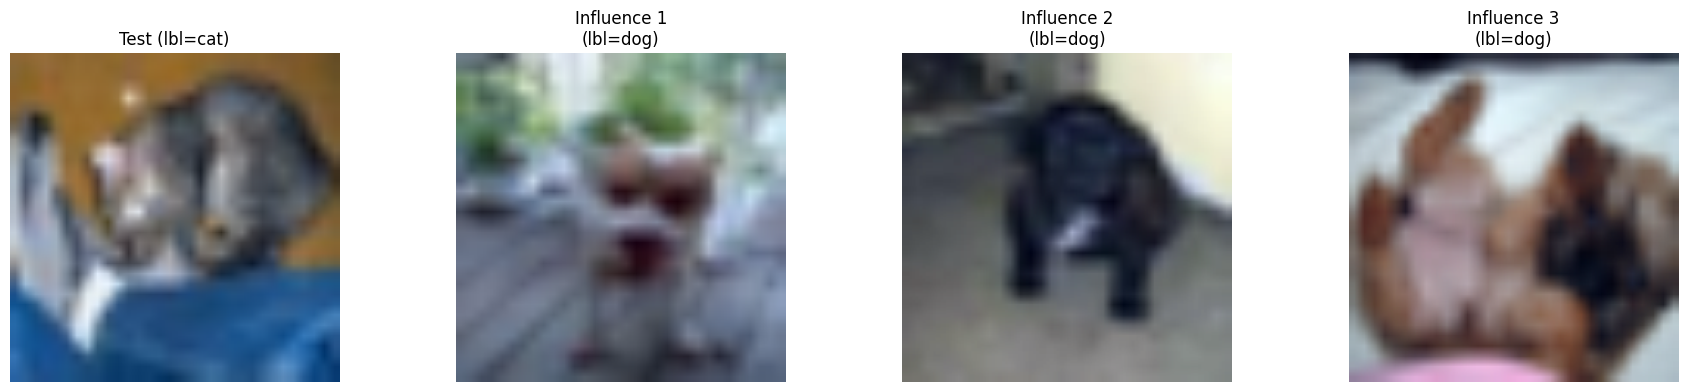

In [11]:
# Your solution here..

topk = sorted(influences, key=lambda x: x[0], reverse=True)[:3]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

def show(img, ax, title):
    img = img.permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")

show(test_img.cpu(), axes[0], f"Test (lbl={class_names[test_lbl]})")
for i, (_, idx) in enumerate(topk):
    img, lbl = train_subset[idx]
    show(img, axes[i + 1], f"Influence {i+1}\n(lbl={class_names[lbl]})")
plt.tight_layout()
plt.show()

### Counterfactuals

In [12]:
adult = fetch_openml(name="adult", version=2, as_frame=True)

X = adult.data
y = adult.target

In [13]:
X.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States


In [14]:
numerical_features = [
    "age",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

categorical_features = [col for col in X.columns if col not in numerical_features]

print("Numerical:", numerical_features)
print("Categorical:", categorical_features)

numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])

categorical_transformer = Pipeline(steps=[("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

Numerical: ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical: ['workclass', 'fnlwgt', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


**Task (0.5 points):** Train a logistic regression on the tabular dataset given.

In [15]:
# Your solution here..

y = y.apply(lambda x: 0 if x == "<=50K" else 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

clf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(max_iter=1000))
])
clf_pipeline.fit(X_train, y_train)

y_pred = clf_pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8525949431876344
              precision    recall  f1-score   support

           0       0.88      0.93      0.91      7431
           1       0.74      0.59      0.66      2338

    accuracy                           0.85      9769
   macro avg       0.81      0.76      0.78      9769
weighted avg       0.85      0.85      0.85      9769



**Task (1.5 points):** Select a negatively predicted test instance and use DiCE to generate baseline counterfactual examples. Show the feature values of the original and the counterfactual.

In [18]:
# Your solution here..

# choose a candidate instance
X_test_copy = X_test.copy()
X_test_copy["true"] = y_test.values
X_test_copy["pred"] = clf_pipeline.predict(X_test)
candidates = X_test_copy[(X_test_copy["pred"] == 0)]
idx = candidates.index[1]
x_orig = X_test.loc[idx:idx]
print("Original prediction:", clf_pipeline.predict(x_orig)[0])
print("Probability of >50K:", clf_pipeline.predict_proba(x_orig)[0, 1])

# DiCE
# Prepare a combined dataframe for DiCE (training data + target)
train_df = X_train.copy()
train_df["target"] = y_train.values

dice_data = dice_ml.Data(
    dataframe=train_df,
    continuous_features=numerical_features + ["fnlwgt"],
    outcome_name="target"
)

dice_model = dice_ml.Model(
    model=clf_pipeline,
    backend="sklearn"
)

explainer = dice_ml.Dice(dice_data, dice_model, method="random")

# Baseline Counterfactual
cf_baseline_result = explainer.generate_counterfactuals(
    query_instances=x_orig,
    total_CFs=1,
    desired_class=1
)
cf_baseline_result.visualize_as_dataframe(show_only_changes=True)

cf_baseline = cf_baseline_result.cf_examples_list[0].final_cfs_df.drop(columns=["target"]).iloc[0:1]
cf_baseline.index = x_orig.index
print("Baseline CF prediction:", clf_pipeline.predict(cf_baseline)[0])
print("Prob:", clf_pipeline.predict_proba(cf_baseline)[0, 1])

all_features = [c for c in X.columns]
pd.DataFrame({
    "original": x_orig.iloc[0],
    "baseline_cf": cf_baseline.iloc[0]
}).loc[all_features]

Original prediction: 0
Probability of >50K: 0.0038123611249104524


100%|██████████| 1/1 [00:00<00:00,  1.62it/s]

Query instance (original outcome : 0)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,28,Local-gov,401886,HS-grad,9,Never-married,Adm-clerical,Other-relative,White,Male,0,0,20,United-States,0



Diverse Counterfactual set (new outcome: 1)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,-,-,-,-,-,-,-,-,-,-,45569,-,-,-,1


Baseline CF prediction: 1
Prob: 0.9998157098617965


,original,baseline_cf
age,28,28
workclass,Local-gov,Local-gov
fnlwgt,401886,401886
education,HS-grad,HS-grad
education-num,9,9
marital-status,Never-married,Never-married
occupation,Adm-clerical,Adm-clerical
relationship,Other-relative,Other-relative
race,White,White
sex,Male,Male


**Task (1.5 points):** Use DiCE's `features_to_vary` to add feasibility constraints to prevent changes to the subset of features that cannot be modified (analyse the features to determine that subset) and compare results.

In [25]:
# Your solution here..

immutable_features = ["age", "race", "sex", "native-country", "fnlwgt"]
mutable_features = [f for f in X.columns if f not in immutable_features]

cf_feasible_result = explainer.generate_counterfactuals(
    query_instances=x_orig,
    total_CFs=1,
    desired_class=1,
    features_to_vary=mutable_features
)
cf_feasible_result.visualize_as_dataframe(show_only_changes=True)

cf_feasible = cf_feasible_result.cf_examples_list[0].final_cfs_df.drop(columns=["target"]).iloc[0:1]
cf_feasible.index = x_orig.index
print("Feasible CF prediction:", clf_pipeline.predict(cf_feasible)[0])
print("Prob:", clf_pipeline.predict_proba(cf_feasible)[0, 1])

pd.DataFrame({
    "original": x_orig.iloc[0],
    "baseline_cf": cf_baseline.iloc[0],
    "feasible_cf": cf_feasible.iloc[0]
}).loc[X.columns]

100%|██████████| 1/1 [00:00<00:00,  2.40it/s]

Query instance (original outcome : 0)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,28,Local-gov,401886,HS-grad,9,Never-married,Adm-clerical,Other-relative,White,Male,0,0,20,United-States,0



Diverse Counterfactual set (new outcome: 1)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,-,-,-,7th-8th,-,-,-,-,-,-,98286,-,-,-,1


Feasible CF prediction: 1
Prob: 0.9999999999874525


,original,baseline_cf,feasible_cf
age,28,28,28
workclass,Local-gov,Local-gov,Local-gov
fnlwgt,401886,401886,401886
education,HS-grad,HS-grad,7th-8th
education-num,9,9,9
marital-status,Never-married,Never-married,Never-married
occupation,Adm-clerical,Adm-clerical,Adm-clerical
relationship,Other-relative,Other-relative,Other-relative
race,White,White,White
sex,Male,Male,Male


**Task (1.5 points):** Add the causal constraints given and generate counterfactuals again. Compare results.

Causal Constraints:
age → education-num \
age → capital-gain \
education-num → hours-per-week \
hours-per-week → capital-gain

In [26]:
# Your solution here..

def enforce_causal_constraints(x_cf, x_orig):
    """Apply domain-driven causal rules as a post-processing step on a counterfactual."""
    x_cf = x_cf.copy()

    # Causal rule 1: age -> education-num
    if x_cf["education-num"].values[0] > x_orig["education-num"].values[0]:
        edu_increase = x_cf["education-num"].values[0] - x_orig["education-num"].values[0]
        x_cf["age"] = max(x_cf["age"].values[0], x_orig["age"].values[0] + edu_increase)

    # Causal rule 2: age -> capital-gain
    if x_cf["capital-gain"].values[0] > x_orig["capital-gain"].values[0]:
        x_cf["age"] = max(x_cf["age"].values[0], x_orig["age"].values[0])

    # Causal rule 3: education-num -> hours-per-week
    if x_cf["education-num"].values[0] > x_orig["education-num"].values[0]:
        x_cf["hours-per-week"] = max(x_cf["hours-per-week"].values[0], x_orig["hours-per-week"].values[0])

    # Causal rule 4: hours-per-week -> capital-gain
    if x_cf["capital-gain"].values[0] > x_orig["capital-gain"].values[0]:
        x_cf["hours-per-week"] = max(x_cf["hours-per-week"].values[0], x_orig["hours-per-week"].values[0])

    return x_cf


cf_causal_result = explainer.generate_counterfactuals(
    query_instances=x_orig,
    total_CFs=25,
    desired_class=1,
    features_to_vary=mutable_features
)
causal_cfs = cf_causal_result.cf_examples_list[0].final_cfs_df.drop(columns=["target"])

causal_candidates = []
for i in range(len(causal_cfs)):
    x_cf = causal_cfs.iloc[i:i+1].copy()
    x_cf.index = x_orig.index
    x_cf = enforce_causal_constraints(x_cf, x_orig)
    if clf_pipeline.predict(x_cf)[0] == 1:
        dist = np.linalg.norm(x_orig[numerical_features].values - x_cf[numerical_features].values)
        causal_candidates.append((dist, x_cf))

if len(causal_candidates) == 0:
    print("No causally valid CF found among generated candidates. Using closest feasible CF with causal adjustment.")
    cf_causal = cf_feasible.copy()
    cf_causal = enforce_causal_constraints(cf_causal, x_orig)
else:
    causal_candidates.sort(key=lambda x: x[0])
    cf_causal = causal_candidates[0][1]

print("Causal CF prediction:", clf_pipeline.predict(cf_causal)[0])
print("Prob:", clf_pipeline.predict_proba(cf_causal)[0, 1])

pd.DataFrame({
    "original": x_orig.iloc[0],
    "feasible_cf": cf_feasible.iloc[0],
    "causal_cf": cf_causal.iloc[0]
}).loc[X.columns]

100%|██████████| 1/1 [00:01<00:00,  1.55s/it]


Causal CF prediction: 1
Prob: 0.5627413851015057


,original,feasible_cf,causal_cf
age,28,28,28
workclass,Local-gov,Local-gov,Local-gov
fnlwgt,401886,401886,401886
education,HS-grad,7th-8th,HS-grad
education-num,9,9,9
marital-status,Never-married,Never-married,Never-married
occupation,Adm-clerical,Adm-clerical,Adm-clerical
relationship,Other-relative,Other-relative,Other-relative
race,White,White,White
sex,Male,Male,Male


**Task (1.5 points):** Use DiCE's `kdtree` method to construct on-manifold counterfactuals. Compare all results.

In [27]:
# Your solution here..

all_features = [c for c in X.columns]

# Use KD-tree method: finds CFs among actual training instances (on-manifold)
# This ensures the CF is a real observed data point, not a synthetic one
explainer_kdtree = dice_ml.Dice(dice_data, dice_model, method="kdtree")
cf_manifold_result = explainer_kdtree.generate_counterfactuals(
    query_instances=x_orig,
    total_CFs=1,
    desired_class=1
)
cf_manifold_result.visualize_as_dataframe(show_only_changes=True)

manifold_cf = cf_manifold_result.cf_examples_list[0].final_cfs_df.drop(columns=["target"]).iloc[0:1]
manifold_cf.index = x_orig.index
print("Manifold CF prediction:", clf_pipeline.predict(manifold_cf)[0])
pd.DataFrame({
    "original": x_orig.iloc[0],
    "manifold_cf": manifold_cf.iloc[0]
}).loc[all_features]

pd.DataFrame({
    "original": x_orig.iloc[0],
    "baseline_cf": cf_baseline.iloc[0],
    "feasible_cf": cf_feasible.iloc[0],
    "causal_cf": cf_causal.iloc[0],
    "manifold_cf": manifold_cf.iloc[0]
}).loc[all_features]

100%|██████████| 1/1 [00:05<00:00,  5.70s/it]

Query instance (original outcome : 0)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,28,Local-gov,401886,HS-grad,9,Never-married,Adm-clerical,Other-relative,White,Male,0,0,20,United-States,0



Diverse Counterfactual set (new outcome: 1)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
9839,71,Self-emp-not-inc,-,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,-,-,-,-,34,-,1


Manifold CF prediction: 1


,original,baseline_cf,feasible_cf,causal_cf,manifold_cf
age,28,28,28,28,71
workclass,Local-gov,Local-gov,Local-gov,Local-gov,Self-emp-not-inc
fnlwgt,401886,401886,401886,401886,401203
education,HS-grad,HS-grad,7th-8th,HS-grad,Bachelors
education-num,9,9,9,9,13
marital-status,Never-married,Never-married,Never-married,Never-married,Married-civ-spouse
occupation,Adm-clerical,Adm-clerical,Adm-clerical,Adm-clerical,Prof-specialty
relationship,Other-relative,Other-relative,Other-relative,Other-relative,Husband
race,White,White,White,White,White
sex,Male,Male,Male,Male,Male


**Task (1 point):** Create a dot plot showing which numerical and categorical features changed for a selected test instance across the base, feasible, causal and manifold counterfactuals.

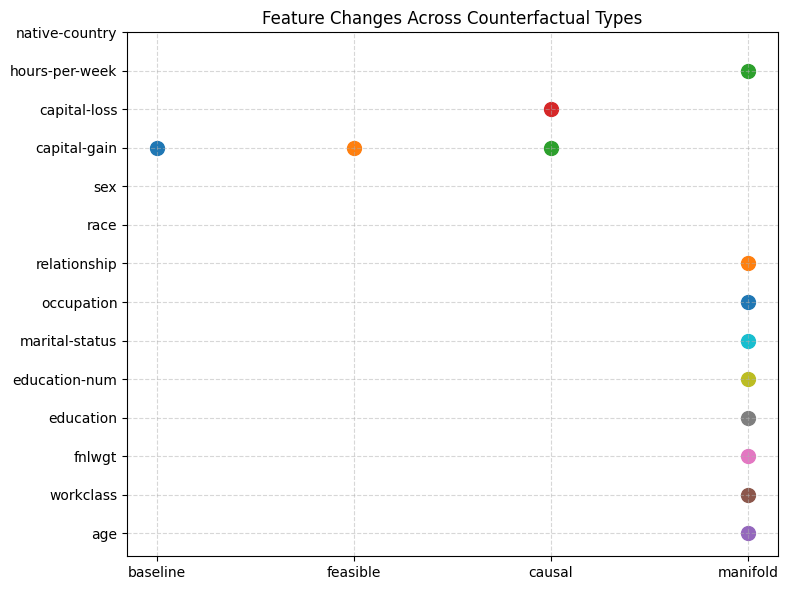

In [24]:
# Your solution here..

import matplotlib.pyplot as plt

cf_df = pd.DataFrame({
    "original": x_orig.iloc[0],
    "baseline": cf_baseline.iloc[0],
    "feasible": cf_feasible.iloc[0],
    "causal": cf_causal.iloc[0],
    "manifold": manifold_cf.iloc[0]
}).loc[all_features]

cf_types = ["baseline", "feasible", "causal", "manifold"]
changed = cf_df[cf_types].ne(cf_df["original"], axis=0)

fig, ax = plt.subplots(figsize=(8, 6))
for i, cf_type in enumerate(cf_types):
    for j, feat in enumerate(all_features):
        if changed.loc[feat, cf_type]:
            ax.scatter(i, j, s=100)

ax.set_xticks(range(len(cf_types)))
ax.set_xticklabels(cf_types)
ax.set_yticks(range(len(all_features)))
ax.set_yticklabels(all_features)
ax.set_title("Feature Changes Across Counterfactual Types")
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()